
  Solving ZDT1 with SPEA2 | pop=100 | archive=100 | gen=200 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/200 | Non-dominated in archive: 26
  Gen  100/200 | Non-dominated in archive: 100
  Gen  150/200 | Non-dominated in archive: 100
  Gen  200/200 | Non-dominated in archive: 100
  ✓ ZDT1 done | Initial pop size: 100 | Final non-dominated size: 100

  Solving ZDT2 with SPEA2 | pop=100 | archive=100 | gen=200 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/200 | Non-dominated in archive: 20
  Gen  100/200 | Non-dominated in archive: 45
  Gen  150/200 | Non-dominated in archive: 100
  Gen  200/200 | Non-dominated in archive: 100
  ✓ ZDT2 done | Initial pop size: 100 | Final non-dominated size: 100

  Solving ZDT3 with SPEA2 | pop=100 | archive=100 | gen=200 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/200 | Non-dominated in archive: 29
  Gen  100/200 | Non-dominated in archive: 84
  Gen  150/200 | Non-dominated in archive: 61
  Gen  200/200 | Non-dominated in archive: 100

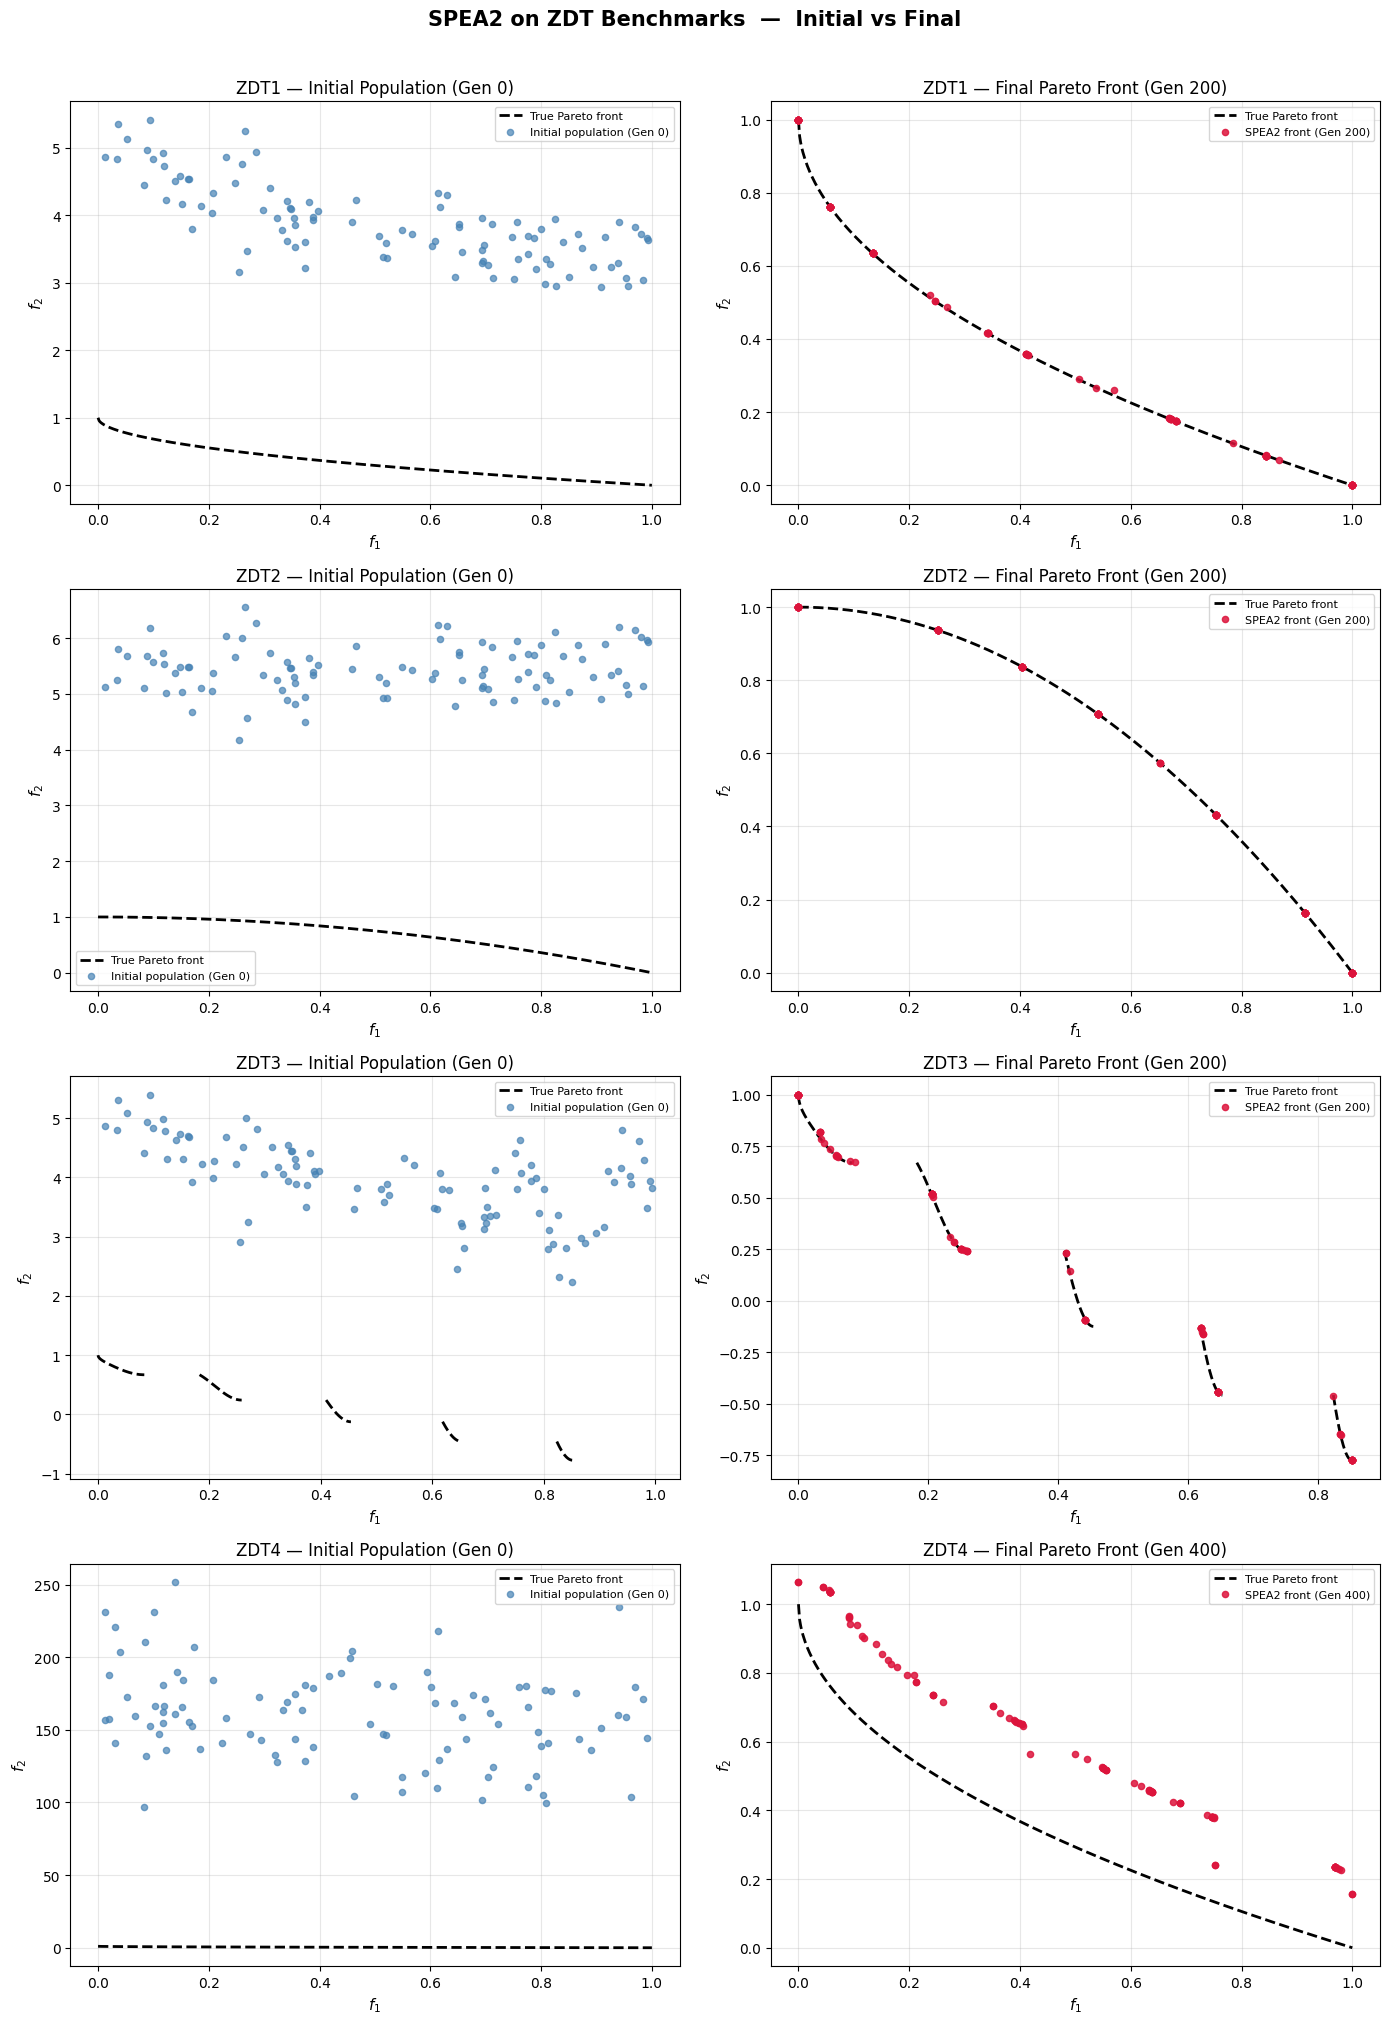

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# -----------------------------------------------------------------------
# ZDT Problem Definitions
# -----------------------------------------------------------------------

def zdt1(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - np.sqrt(f1 / g)
    return np.array([f1, g * h])

def zdt2(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - (f1 / g) ** 2
    return np.array([f1, g * h])

def zdt3(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - np.sqrt(f1 / g) - (f1 / g) * np.sin(10 * np.pi * f1)
    return np.array([f1, g * h])

def zdt4(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 10 * (n - 1) + np.sum(x[1:] ** 2 - 10 * np.cos(4 * np.pi * x[1:]))
    h = 1 - np.sqrt(f1 / g)
    return np.array([f1, g * h])

# -----------------------------------------------------------------------
# True Pareto Fronts
# -----------------------------------------------------------------------

def true_pareto_zdt1():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - np.sqrt(f1)

def true_pareto_zdt2():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - f1 ** 2

def true_pareto_zdt3():
    intervals = [
        (0.0000, 0.0830), (0.1822, 0.2577), (0.4093, 0.4538),
        (0.6183, 0.6525), (0.8233, 0.8518)
    ]
    f1_list, f2_list = [], []
    for a, b in intervals:
        f1 = np.linspace(a, b, 200)
        f2 = 1 - np.sqrt(f1) - f1 * np.sin(10 * np.pi * f1)
        f1_list.extend(list(f1) + [np.nan])
        f2_list.extend(list(f2) + [np.nan])
    return np.array(f1_list[:-1]), np.array(f2_list[:-1])

def true_pareto_zdt4():
    return true_pareto_zdt1()

# -----------------------------------------------------------------------
# SPEA2 Core Functions
# -----------------------------------------------------------------------

class Individual:
    __slots__ = ('x', 'obj', 'S', 'R', 'sigma_k', 'D', 'F')
    def __init__(self, x):
        self.x = np.array(x, dtype=float)
        self.obj = None
        self.S = 0
        self.R = 0
        self.sigma_k = 0.0
        self.D = 0.0
        self.F = 0.0

def dominates(a, b):
    """Return True if a dominates b (minimisation)."""
    return (a.obj[0] <= b.obj[0] and a.obj[1] <= b.obj[1]) and \
           (a.obj[0] < b.obj[0] or a.obj[1] < b.obj[1])

def compute_fitness(pop, k_neighbour):
    n = len(pop)
    if n == 0:
        return
    # Strength S(i)
    for i in range(n):
        pop[i].S = 0
        for j in range(n):
            if i != j and dominates(pop[i], pop[j]):
                pop[i].S += 1
    # Raw fitness R(i)
    for i in range(n):
        total = 0
        for j in range(n):
            if j != i and dominates(pop[j], pop[i]):
                total += pop[j].S
        pop[i].R = total
    # Density D(i)
    if n > 1:
        objs = np.array([ind.obj for ind in pop])
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i != j:
                    dist[i, j] = np.linalg.norm(objs[i] - objs[j])
                else:
                    dist[i, j] = np.inf
        k = min(k_neighbour, n-1)
        for i in range(n):
            sorted_dist = np.sort(dist[i])
            pop[i].sigma_k = sorted_dist[k-1]
            pop[i].D = 1.0 / (pop[i].sigma_k + 2.0)
    else:
        pop[0].D = 1.0
    # Final fitness
    for i in range(n):
        pop[i].F = pop[i].R + pop[i].D

def truncation(non_dom, target_size, k_neighbour):
    archive = deepcopy(non_dom)
    while len(archive) > target_size:
        n = len(archive)
        objs = np.array([ind.obj for ind in archive])
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i != j:
                    dist[i, j] = np.linalg.norm(objs[i] - objs[j])
                else:
                    dist[i, j] = np.inf
        k = min(k_neighbour, n-1)
        sigma_vals = []
        for i in range(n):
            sorted_dist = np.sort(dist[i])
            sigma_vals.append(sorted_dist[k-1])
        idx_remove = np.argmin(sigma_vals)
        archive.pop(idx_remove)
    return archive

def build_archive(C, archive_size, k_neighbour):
    nondom = [ind for ind in C if ind.F < 1.0]
    n_nd = len(nondom)
    if n_nd == archive_size:
        return nondom
    elif n_nd < archive_size:
        new_archive = nondom[:]
        dominated = [ind for ind in C if ind.F >= 1.0]
        dominated.sort(key=lambda ind: ind.F)
        needed = archive_size - len(new_archive)
        new_archive.extend(dominated[:needed])
        return new_archive
    else:
        return truncation(nondom, archive_size, k_neighbour)

def binary_tournament(archive, pop_size):
    mating_pool = []
    for _ in range(pop_size):
        a, b = np.random.choice(len(archive), size=2, replace=False)
        if archive[a].F < archive[b].F:
            mating_pool.append(deepcopy(archive[a]))
        else:
            mating_pool.append(deepcopy(archive[b]))
    return mating_pool

def sbx_crossover(p1, p2, prob_cross, eta_c, xl, xu):
    """Simulated binary crossover with per-variable bounds."""
    if np.random.rand() > prob_cross:
        return deepcopy(p1), deepcopy(p2)
    c1 = deepcopy(p1)
    c2 = deepcopy(p2)
    for i in range(len(p1.x)):
        if np.random.rand() < 0.5:
            u = np.random.rand()
            if u <= 0.5:
                beta = (2.0 * u) ** (1.0 / (eta_c + 1.0))
            else:
                beta = (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (eta_c + 1.0))
            x1 = p1.x[i]
            x2 = p2.x[i]
            y1 = 0.5 * (x1 + x2) - beta * (x2 - x1)
            y2 = 0.5 * (x1 + x2) + beta * (x2 - x1)
            c1.x[i] = np.clip(y1, xl[i], xu[i])
            c2.x[i] = np.clip(y2, xl[i], xu[i])
    return c1, c2

def polynomial_mutation(ind, prob_mut, eta_m, xl, xu):
    """Polynomial mutation with per-variable bounds."""
    child = deepcopy(ind)
    for i in range(len(child.x)):
        if np.random.rand() <= prob_mut:
            r = np.random.rand()
            if r < 0.5:
                delta = (2.0 * r) ** (1.0 / (eta_m + 1.0)) - 1.0
            else:
                delta = 1.0 - (2.0 * (1.0 - r)) ** (1.0 / (eta_m + 1.0))
            range_i = xu[i] - xl[i]
            new_val = child.x[i] + range_i * delta
            child.x[i] = np.clip(new_val, xl[i], xu[i])
    return child

# -----------------------------------------------------------------------
# FIX: Helper to extract true non-dominated front within a set
# -----------------------------------------------------------------------

def get_nondominated(population):
    """
    Return only the non-dominated individuals by re-checking dominance
    purely within 'population' — independent of any stale F values.
    """
    non_dom = []
    for i, ind in enumerate(population):
        dominated = False
        for j, other in enumerate(population):
            if j != i and dominates(other, ind):
                dominated = True
                break
        if not dominated:
            non_dom.append(ind)
    return non_dom

# -----------------------------------------------------------------------
# Main SPEA2 Loop
# -----------------------------------------------------------------------

def spea2(problem_func, n_var, bounds,
          pop_size=100, archive_size=100, n_gen=200,
          prob_cross=0.9, prob_mut=None, eta_c=15, eta_m=20, seed=42):
    """
    Returns
    -------
    final_front : ndarray
        Non-dominated objective vectors from the final archive.
        Sorted by f1.
    init_objs   : ndarray
        Objective vectors of the initial random population.
    """
    np.random.seed(seed)

    xl = np.array([b[0] for b in bounds])
    xu = np.array([b[1] for b in bounds])

    if prob_mut is None:
        prob_mut = 1.0 / n_var

    k_neighbour = int(np.sqrt(pop_size + archive_size))

    # --- Initialisation ---
    P = []
    for _ in range(pop_size):
        x = np.array([np.random.uniform(xl[j], xu[j]) for j in range(n_var)])
        P.append(Individual(x))

    for ind in P:
        ind.obj = problem_func(ind.x)
    compute_fitness(P, k_neighbour)
    A = build_archive(P, archive_size, k_neighbour)

    # Save initial objectives for plotting
    init_objs = np.array([ind.obj for ind in P])

    # --- Generational loop ---
    for gen in range(n_gen):
        M = binary_tournament(A, pop_size)
        P_next = []
        for i in range(0, pop_size, 2):
            if i+1 < pop_size:
                c1, c2 = sbx_crossover(M[i], M[i+1], prob_cross, eta_c, xl, xu)
            else:
                c1, c2 = deepcopy(M[i]), deepcopy(M[i])
            c1 = polynomial_mutation(c1, prob_mut, eta_m, xl, xu)
            c2 = polynomial_mutation(c2, prob_mut, eta_m, xl, xu)
            c1.obj = problem_func(c1.x)
            c2.obj = problem_func(c2.x)
            P_next.extend([c1, c2])

        C = P_next + A
        compute_fitness(C, k_neighbour)
        A = build_archive(C, archive_size, k_neighbour)

        if (gen + 1) % 50 == 0:
            nd_count = len(get_nondominated(A))
            print(f"  Gen {gen+1:4d}/{n_gen} | Non-dominated in archive: {nd_count}")

    # ---------------------------------------------------------------
    # FIX: Re-extract the true non-dominated front from the final
    # archive by checking dominance within A only — not using stale
    # F values that were computed over the much larger combined pool C.
    # ---------------------------------------------------------------
    final_non_dom = get_nondominated(A)

    # Fallback: if somehow empty, return the full archive
    if len(final_non_dom) == 0:
        final_non_dom = A

    final_front = np.array([ind.obj for ind in final_non_dom])
    if len(final_front) > 0:
        final_front = final_front[np.argsort(final_front[:, 0])]

    return final_front, init_objs

# -----------------------------------------------------------------------
# Plotting helper
# -----------------------------------------------------------------------

def plot_problem(ax_init, ax_final, name,
                 init_objs, final_front,
                 f1_true, f2_true, n_gen):
    """Left: initial random population, Right: final SPEA2 front."""
    # Initial population
    ax_init.plot(f1_true, f2_true, 'k--', linewidth=2,
                 label='True Pareto front', zorder=2)
    ax_init.scatter(init_objs[:, 0], init_objs[:, 1],
                    c='steelblue', s=20, alpha=0.7,
                    label='Initial population (Gen 0)', zorder=3)
    ax_init.set_xlabel('$f_1$', fontsize=11)
    ax_init.set_ylabel('$f_2$', fontsize=11)
    ax_init.set_title(f'{name} — Initial Population (Gen 0)', fontsize=12)
    ax_init.legend(fontsize=8)
    ax_init.grid(True, alpha=0.3)

    # Final non-dominated front
    ax_final.plot(f1_true, f2_true, 'k--', linewidth=2,
                  label='True Pareto front', zorder=2)
    if len(final_front) > 0:
        ax_final.scatter(final_front[:, 0], final_front[:, 1],
                         c='crimson', s=20, alpha=0.85,
                         label=f'SPEA2 front (Gen {n_gen})', zorder=3)
    ax_final.set_xlabel('$f_1$', fontsize=11)
    ax_final.set_ylabel('$f_2$', fontsize=11)
    ax_final.set_title(f'{name} — Final Pareto Front (Gen {n_gen})', fontsize=12)
    ax_final.legend(fontsize=8)
    ax_final.grid(True, alpha=0.3)

# -----------------------------------------------------------------------
# Main: run SPEA2 on all ZDT problems and produce comparison figure
# -----------------------------------------------------------------------

def main():
    problems = [
        # (name,  func,  n_var, bounds,                  true_front_fn,    n_gen)
        ("ZDT1", zdt1, 30, [(0, 1)] * 30,             true_pareto_zdt1, 200),
        ("ZDT2", zdt2, 30, [(0, 1)] * 30,             true_pareto_zdt2, 200),
        ("ZDT3", zdt3, 30, [(0, 1)] * 30,             true_pareto_zdt3, 200),
        ("ZDT4", zdt4, 10, [(0, 1)] + [(-5, 5)] * 9,  true_pareto_zdt4, 400),
    ]

    n_problems = len(problems)
    fig, axes = plt.subplots(n_problems, 2,
                             figsize=(14, 5 * n_problems))

    for row, (name, func, n_var, bounds, true_func, n_gen) in enumerate(problems):
        print(f"\n{'='*60}")
        print(f"  Solving {name} with SPEA2 | pop=100 | archive=100 | gen={n_gen} | "
              f"pc=0.9 | pm=1/n | eta_c=15 | eta_m=20")
        print(f"{'='*60}")

        final_front, init_objs = spea2(
            func, n_var, bounds,
            pop_size=100, archive_size=100, n_gen=n_gen,
            prob_cross=0.9, prob_mut=None,
            eta_c=15, eta_m=20, seed=42
        )

        f1_true, f2_true = true_func()

        ax_init  = axes[row, 0]
        ax_final = axes[row, 1]
        plot_problem(ax_init, ax_final, name,
                     init_objs, final_front,
                     f1_true, f2_true, n_gen)

        print(f"  ✓ {name} done | Initial pop size: {len(init_objs)} | "
              f"Final non-dominated size: {len(final_front)}")

    plt.suptitle('SPEA2 on ZDT Benchmarks  —  Initial vs Final',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('ZDT_SPEA2_initial_vs_final.png', dpi=150, bbox_inches='tight')
    print("\nPlot saved as ZDT_SPEA2_initial_vs_final.png")
    plt.show()

if __name__ == "__main__":
    main()


  Solving ZDT1 with SPEA2 | pop=100 | archive=100 | gen=400 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/400 | Non-dominated in archive: 26
  Gen  100/400 | Non-dominated in archive: 100
  Gen  150/400 | Non-dominated in archive: 100
  Gen  200/400 | Non-dominated in archive: 100
  Gen  250/400 | Non-dominated in archive: 100
  Gen  300/400 | Non-dominated in archive: 100
  Gen  350/400 | Non-dominated in archive: 100
  Gen  400/400 | Non-dominated in archive: 100
  ✓ ZDT1 done | Initial pop size: 100 | Final non-dominated size: 100

  Solving ZDT2 with SPEA2 | pop=100 | archive=100 | gen=400 | pc=0.9 | pm=1/n | eta_c=15 | eta_m=20
  Gen   50/400 | Non-dominated in archive: 20
  Gen  100/400 | Non-dominated in archive: 45
  Gen  150/400 | Non-dominated in archive: 100
  Gen  200/400 | Non-dominated in archive: 100
  Gen  250/400 | Non-dominated in archive: 100
  Gen  300/400 | Non-dominated in archive: 100
  Gen  350/400 | Non-dominated in archive: 100
  Gen  400/400 | Non-domin

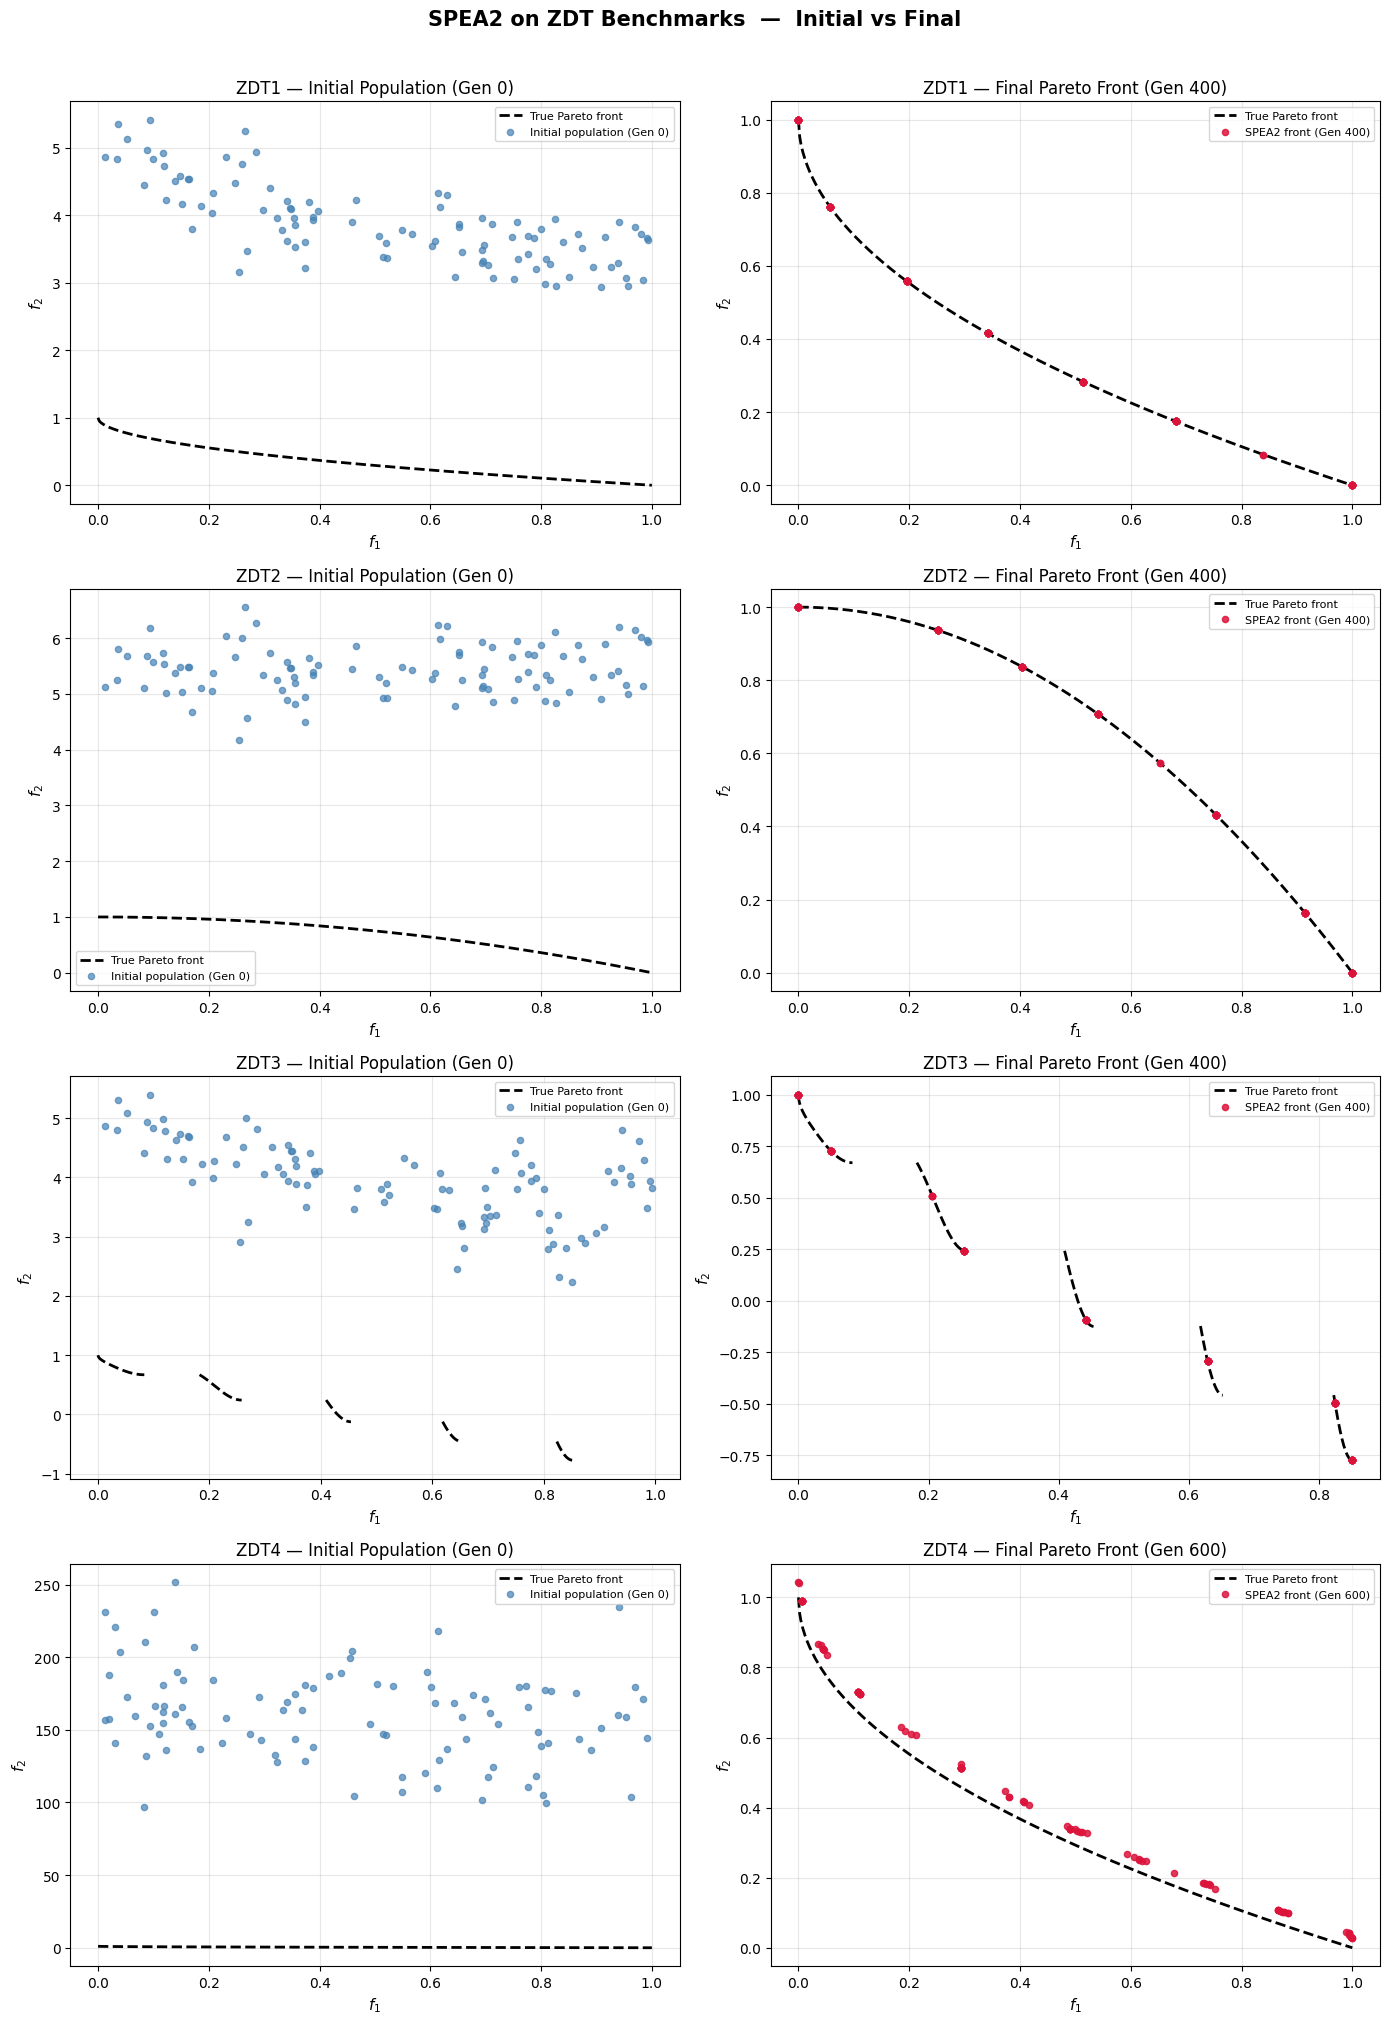

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

# -----------------------------------------------------------------------
# ZDT Problem Definitions
# -----------------------------------------------------------------------

def zdt1(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - np.sqrt(f1 / g)
    return np.array([f1, g * h])

def zdt2(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - (f1 / g) ** 2
    return np.array([f1, g * h])

def zdt3(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / (n - 1)
    h = 1 - np.sqrt(f1 / g) - (f1 / g) * np.sin(10 * np.pi * f1)
    return np.array([f1, g * h])

def zdt4(x):
    n = len(x)
    f1 = x[0]
    g = 1 + 10 * (n - 1) + np.sum(x[1:] ** 2 - 10 * np.cos(4 * np.pi * x[1:]))
    h = 1 - np.sqrt(f1 / g)
    return np.array([f1, g * h])

# -----------------------------------------------------------------------
# True Pareto Fronts
# -----------------------------------------------------------------------

def true_pareto_zdt1():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - np.sqrt(f1)

def true_pareto_zdt2():
    f1 = np.linspace(0, 1, 500)
    return f1, 1 - f1 ** 2

def true_pareto_zdt3():
    intervals = [
        (0.0000, 0.0830), (0.1822, 0.2577), (0.4093, 0.4538),
        (0.6183, 0.6525), (0.8233, 0.8518)
    ]
    f1_list, f2_list = [], []
    for a, b in intervals:
        f1 = np.linspace(a, b, 200)
        f2 = 1 - np.sqrt(f1) - f1 * np.sin(10 * np.pi * f1)
        f1_list.extend(list(f1) + [np.nan])
        f2_list.extend(list(f2) + [np.nan])
    return np.array(f1_list[:-1]), np.array(f2_list[:-1])

def true_pareto_zdt4():
    return true_pareto_zdt1()

# -----------------------------------------------------------------------
# SPEA2 Core Functions
# -----------------------------------------------------------------------

class Individual:
    __slots__ = ('x', 'obj', 'S', 'R', 'sigma_k', 'D', 'F')
    def __init__(self, x):
        self.x = np.array(x, dtype=float)
        self.obj = None
        self.S = 0
        self.R = 0
        self.sigma_k = 0.0
        self.D = 0.0
        self.F = 0.0

def dominates(a, b):
    """Return True if a dominates b (minimisation)."""
    return (a.obj[0] <= b.obj[0] and a.obj[1] <= b.obj[1]) and \
           (a.obj[0] < b.obj[0] or a.obj[1] < b.obj[1])

def compute_fitness(pop, k_neighbour):
    n = len(pop)
    if n == 0:
        return
    # Strength S(i)
    for i in range(n):
        pop[i].S = 0
        for j in range(n):
            if i != j and dominates(pop[i], pop[j]):
                pop[i].S += 1
    # Raw fitness R(i)
    for i in range(n):
        total = 0
        for j in range(n):
            if j != i and dominates(pop[j], pop[i]):
                total += pop[j].S
        pop[i].R = total
    # Density D(i)
    if n > 1:
        objs = np.array([ind.obj for ind in pop])
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i != j:
                    dist[i, j] = np.linalg.norm(objs[i] - objs[j])
                else:
                    dist[i, j] = np.inf
        k = min(k_neighbour, n-1)
        for i in range(n):
            sorted_dist = np.sort(dist[i])
            pop[i].sigma_k = sorted_dist[k-1]
            pop[i].D = 1.0 / (pop[i].sigma_k + 2.0)
    else:
        pop[0].D = 1.0
    # Final fitness
    for i in range(n):
        pop[i].F = pop[i].R + pop[i].D

def truncation(non_dom, target_size, k_neighbour):
    archive = deepcopy(non_dom)
    while len(archive) > target_size:
        n = len(archive)
        objs = np.array([ind.obj for ind in archive])
        dist = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i != j:
                    dist[i, j] = np.linalg.norm(objs[i] - objs[j])
                else:
                    dist[i, j] = np.inf
        k = min(k_neighbour, n-1)
        sigma_vals = []
        for i in range(n):
            sorted_dist = np.sort(dist[i])
            sigma_vals.append(sorted_dist[k-1])
        idx_remove = np.argmin(sigma_vals)
        archive.pop(idx_remove)
    return archive

def build_archive(C, archive_size, k_neighbour):
    nondom = [ind for ind in C if ind.F < 1.0]
    n_nd = len(nondom)
    if n_nd == archive_size:
        return nondom
    elif n_nd < archive_size:
        new_archive = nondom[:]
        dominated = [ind for ind in C if ind.F >= 1.0]
        dominated.sort(key=lambda ind: ind.F)
        needed = archive_size - len(new_archive)
        new_archive.extend(dominated[:needed])
        return new_archive
    else:
        return truncation(nondom, archive_size, k_neighbour)

def binary_tournament(archive, pop_size):
    mating_pool = []
    for _ in range(pop_size):
        a, b = np.random.choice(len(archive), size=2, replace=False)
        if archive[a].F < archive[b].F:
            mating_pool.append(deepcopy(archive[a]))
        else:
            mating_pool.append(deepcopy(archive[b]))
    return mating_pool

def sbx_crossover(p1, p2, prob_cross, eta_c, xl, xu):
    """Simulated binary crossover with per-variable bounds."""
    if np.random.rand() > prob_cross:
        return deepcopy(p1), deepcopy(p2)
    c1 = deepcopy(p1)
    c2 = deepcopy(p2)
    for i in range(len(p1.x)):
        if np.random.rand() < 0.5:
            u = np.random.rand()
            if u <= 0.5:
                beta = (2.0 * u) ** (1.0 / (eta_c + 1.0))
            else:
                beta = (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (eta_c + 1.0))
            x1 = p1.x[i]
            x2 = p2.x[i]
            y1 = 0.5 * (x1 + x2) - beta * (x2 - x1)
            y2 = 0.5 * (x1 + x2) + beta * (x2 - x1)
            c1.x[i] = np.clip(y1, xl[i], xu[i])
            c2.x[i] = np.clip(y2, xl[i], xu[i])
    return c1, c2

def polynomial_mutation(ind, prob_mut, eta_m, xl, xu):
    """Polynomial mutation with per-variable bounds."""
    child = deepcopy(ind)
    for i in range(len(child.x)):
        if np.random.rand() <= prob_mut:
            r = np.random.rand()
            if r < 0.5:
                delta = (2.0 * r) ** (1.0 / (eta_m + 1.0)) - 1.0
            else:
                delta = 1.0 - (2.0 * (1.0 - r)) ** (1.0 / (eta_m + 1.0))
            range_i = xu[i] - xl[i]
            new_val = child.x[i] + range_i * delta
            child.x[i] = np.clip(new_val, xl[i], xu[i])
    return child

# -----------------------------------------------------------------------
# FIX: Helper to extract true non-dominated front within a set
# -----------------------------------------------------------------------

def get_nondominated(population):
    """
    Return only the non-dominated individuals by re-checking dominance
    purely within 'population' — independent of any stale F values.
    """
    non_dom = []
    for i, ind in enumerate(population):
        dominated = False
        for j, other in enumerate(population):
            if j != i and dominates(other, ind):
                dominated = True
                break
        if not dominated:
            non_dom.append(ind)
    return non_dom

# -----------------------------------------------------------------------
# Main SPEA2 Loop
# -----------------------------------------------------------------------

def spea2(problem_func, n_var, bounds,
          pop_size=100, archive_size=100, n_gen=200,
          prob_cross=0.9, prob_mut=None, eta_c=15, eta_m=20, seed=42):
    """
    Returns
    -------
    final_front : ndarray
        Non-dominated objective vectors from the final archive.
        Sorted by f1.
    init_objs   : ndarray
        Objective vectors of the initial random population.
    """
    np.random.seed(seed)

    xl = np.array([b[0] for b in bounds])
    xu = np.array([b[1] for b in bounds])

    if prob_mut is None:
        prob_mut = 1.0 / n_var

    k_neighbour = int(np.sqrt(pop_size + archive_size))

    # --- Initialisation ---
    P = []
    for _ in range(pop_size):
        x = np.array([np.random.uniform(xl[j], xu[j]) for j in range(n_var)])
        P.append(Individual(x))

    for ind in P:
        ind.obj = problem_func(ind.x)
    compute_fitness(P, k_neighbour)
    A = build_archive(P, archive_size, k_neighbour)

    # Save initial objectives for plotting
    init_objs = np.array([ind.obj for ind in P])

    # --- Generational loop ---
    for gen in range(n_gen):
        M = binary_tournament(A, pop_size)
        P_next = []
        for i in range(0, pop_size, 2):
            if i+1 < pop_size:
                c1, c2 = sbx_crossover(M[i], M[i+1], prob_cross, eta_c, xl, xu)
            else:
                c1, c2 = deepcopy(M[i]), deepcopy(M[i])
            c1 = polynomial_mutation(c1, prob_mut, eta_m, xl, xu)
            c2 = polynomial_mutation(c2, prob_mut, eta_m, xl, xu)
            c1.obj = problem_func(c1.x)
            c2.obj = problem_func(c2.x)
            P_next.extend([c1, c2])

        C = P_next + A
        compute_fitness(C, k_neighbour)
        A = build_archive(C, archive_size, k_neighbour)

        if (gen + 1) % 50 == 0:
            nd_count = len(get_nondominated(A))
            print(f"  Gen {gen+1:4d}/{n_gen} | Non-dominated in archive: {nd_count}")

    # ---------------------------------------------------------------
    # FIX: Re-extract the true non-dominated front from the final
    # archive by checking dominance within A only — not using stale
    # F values that were computed over the much larger combined pool C.
    # ---------------------------------------------------------------
    final_non_dom = get_nondominated(A)

    # Fallback: if somehow empty, return the full archive
    if len(final_non_dom) == 0:
        final_non_dom = A

    final_front = np.array([ind.obj for ind in final_non_dom])
    if len(final_front) > 0:
        final_front = final_front[np.argsort(final_front[:, 0])]

    return final_front, init_objs

# -----------------------------------------------------------------------
# Plotting helper
# -----------------------------------------------------------------------

def plot_problem(ax_init, ax_final, name,
                 init_objs, final_front,
                 f1_true, f2_true, n_gen):
    """Left: initial random population, Right: final SPEA2 front."""
    # Initial population
    ax_init.plot(f1_true, f2_true, 'k--', linewidth=2,
                 label='True Pareto front', zorder=2)
    ax_init.scatter(init_objs[:, 0], init_objs[:, 1],
                    c='steelblue', s=20, alpha=0.7,
                    label='Initial population (Gen 0)', zorder=3)
    ax_init.set_xlabel('$f_1$', fontsize=11)
    ax_init.set_ylabel('$f_2$', fontsize=11)
    ax_init.set_title(f'{name} — Initial Population (Gen 0)', fontsize=12)
    ax_init.legend(fontsize=8)
    ax_init.grid(True, alpha=0.3)

    # Final non-dominated front
    ax_final.plot(f1_true, f2_true, 'k--', linewidth=2,
                  label='True Pareto front', zorder=2)
    if len(final_front) > 0:
        ax_final.scatter(final_front[:, 0], final_front[:, 1],
                         c='crimson', s=20, alpha=0.85,
                         label=f'SPEA2 front (Gen {n_gen})', zorder=3)
    ax_final.set_xlabel('$f_1$', fontsize=11)
    ax_final.set_ylabel('$f_2$', fontsize=11)
    ax_final.set_title(f'{name} — Final Pareto Front (Gen {n_gen})', fontsize=12)
    ax_final.legend(fontsize=8)
    ax_final.grid(True, alpha=0.3)

# -----------------------------------------------------------------------
# Main: run SPEA2 on all ZDT problems and produce comparison figure
# -----------------------------------------------------------------------

def main():
    problems = [
        # (name,  func,  n_var, bounds,                  true_front_fn,    n_gen)
        ("ZDT1", zdt1, 30, [(0, 1)] * 30,             true_pareto_zdt1, 400),
        ("ZDT2", zdt2, 30, [(0, 1)] * 30,             true_pareto_zdt2, 400),
        ("ZDT3", zdt3, 30, [(0, 1)] * 30,             true_pareto_zdt3, 400),
        ("ZDT4", zdt4, 10, [(0, 1)] + [(-5, 5)] * 9,  true_pareto_zdt4, 600),
    ]

    n_problems = len(problems)
    fig, axes = plt.subplots(n_problems, 2,
                             figsize=(14, 5 * n_problems))

    for row, (name, func, n_var, bounds, true_func, n_gen) in enumerate(problems):
        print(f"\n{'='*60}")
        print(f"  Solving {name} with SPEA2 | pop=100 | archive=100 | gen={n_gen} | "
              f"pc=0.9 | pm=1/n | eta_c=15 | eta_m=20")
        print(f"{'='*60}")

        final_front, init_objs = spea2(
            func, n_var, bounds,
            pop_size=100, archive_size=100, n_gen=n_gen,
            prob_cross=0.9, prob_mut=None,
            eta_c=15, eta_m=20, seed=42
        )

        f1_true, f2_true = true_func()

        ax_init  = axes[row, 0]
        ax_final = axes[row, 1]
        plot_problem(ax_init, ax_final, name,
                     init_objs, final_front,
                     f1_true, f2_true, n_gen)

        print(f"  ✓ {name} done | Initial pop size: {len(init_objs)} | "
              f"Final non-dominated size: {len(final_front)}")

    plt.suptitle('SPEA2 on ZDT Benchmarks  —  Initial vs Final',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('ZDT_SPEA2_initial_vs_final.png', dpi=150, bbox_inches='tight')
    print("\nPlot saved as ZDT_SPEA2_initial_vs_final.png")
    plt.show()

if __name__ == "__main__":
    main()